# **Seismic Inversion FWI - FPN**

# **0. Install tensorflow probability**


In [1]:
import tensorflow as tf
print(tf.__version__)

2026-09-06 10:06:23.024736: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-06 10:06:23.088934: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-06 10:06:23.091190: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-06 10:06:23.091199: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore 

2.11.0


## **1. Python libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

In [3]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


2026-09-06 10:06:24.598335: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-09-06 10:06:24.601524: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-09-06 10:06:24.601559: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-09-06 10:06:24.601582: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-09-06 10:06:24.601604: W tensorflow/c

In [4]:
!nvidia-smi

Sun Sep  6 10:06:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070 Ti     Off |   00000000:01:00.0  On |                  N/A |
|  0%   43C    P8             25W /  310W |     460MiB /   8192MiB |     18%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **2. Paths**

### **2.1. Traces - InputData**

In [5]:
dirTraceTrain = "../Data/kimberlina_co2_train_data"
dirTraceVal = "../Data/kimberlina_co2_test_data"

### **2.2. Velocity - OutputData**

In [6]:
dirModelTrain = "../Model/kimberlina_co2_train_label"
dirModelVal = "../Model/kimberlina_co2_test_label"

### **2.3. Directory for saved trained models**

In [7]:
dirModelTrained="../ModelTrained/"
dirModel="../Model/"

### **2.4. Trained models directory**

In [8]:
dirImages = "../Images/"

## **3. Load list Paths**

### **3.1. Load list path Data Traces - Input**

In [9]:
TracePaths_train = sorted(
    os.path.join(dirTraceTrain, f)
    for f in os.listdir(dirTraceTrain)
    if f.endswith(".npz")
)


In [10]:
len(TracePaths_train)

15000

In [11]:
TracePaths_val = sorted(
    os.path.join(dirTraceVal, f)
    for f in os.listdir(dirTraceVal)
    if f.endswith(".npz")
)

In [12]:
len(TracePaths_val)

4430

### **3.2. Load Path Data Velocity - Output**

In [13]:
ModelPaths_train = sorted(
    os.path.join(dirModelTrain, f)
    for f in os.listdir(dirModelTrain)
    if f.endswith(".npz")
)

In [14]:
len(ModelPaths_train)

15000

In [15]:
ModelPaths_val = sorted(
    os.path.join(dirModelVal, f)
    for f in os.listdir(dirModelVal)
    if f.endswith(".npz")
)

In [16]:
len(ModelPaths_val)

4430

### **3.3.Splits**

In [17]:
# Semilla para reproducibilidad
random.seed(42)

nTest = 1000   # número de rutas para el test set, extraídas de train
nCal = 100    # número de rutas para el calibration set, extraídas de train

assert len(TracePaths_train) == len(ModelPaths_train), \
    "TracePaths_train y ModelPaths_train deben tener el mismo largo (pares input/output)"

# Generar índices mezclados para mantener la correspondencia input-output
indices = list(range(len(TracePaths_train)))
random.shuffle(indices)

test_idx = indices[:nTest]
cal_idx = indices[nTest:nTest + nCal]
train_idx = indices[nTest + nCal:]

# Aplicar los índices a ambas listas (trace y model) para no romper la correspondencia
TracePaths_test = [TracePaths_train[i] for i in test_idx]
ModelPaths_test = [ModelPaths_train[i] for i in test_idx]

TracePaths_cal = [TracePaths_train[i] for i in cal_idx]
ModelPaths_cal = [ModelPaths_train[i] for i in cal_idx]

TracePaths_train_final = [TracePaths_train[i] for i in train_idx]
ModelPaths_train_final = [ModelPaths_train[i] for i in train_idx]

print(f"Train final: {len(TracePaths_train_final)} pares")
print(f"Test: {len(TracePaths_test)} pares")
print(f"Calibration: {len(TracePaths_cal)} pares")
print(f"Validation (sin cambios): {len(TracePaths_val)} pares")

Train final: 13900 pares
Test: 1000 pares
Calibration: 100 pares
Validation (sin cambios): 4430 pares


### **3.4. Vmin and Vmax - Set Train**

In [18]:
vmin_global = np.inf
vmax_global = -np.inf

for path in ModelPaths_train:
    label = np.load(path)['label']
    vmin_global = min(vmin_global, label.min())
    vmax_global = max(vmax_global, label.max())

print(f"Min velocity: {vmin_global:.2f} m/s")
print(f"Max velocity: {vmax_global:.2f} m/s")

Min velocity: 951.82 m/s
Max velocity: 2546.00 m/s


# **4. Batch Creation**

In [19]:
import cv2

class SeismicSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        trace_paths,
        model_paths,
        batch_size=8,
        shuffle=True,
        target_size=(288,96)#(128, 128)
    ):
        self.trace_paths = trace_paths
        self.model_paths = model_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.target_size = target_size
        self.n_models = len(trace_paths)
        self.indices = np.arange(self.n_models)
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(self.n_models / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]

        X_batch = []
        y_batch = []

        H, W = self.target_size

        for i in batch_indices:
            X = np.load(self.trace_paths[i])['data']   # (9, 1251, 101)
            y = np.load(self.model_paths[i])['label']  # (401, 141)

            y_resized = cv2.resize(y, (W, H), interpolation=cv2.INTER_LINEAR)  # (128, 128)

            X_batch.append(X)
            y_batch.append(y_resized)

        X_batch = np.asarray(X_batch, dtype=np.float32)   # (batch, 9, 1251, 101)
        y_batch = np.asarray(y_batch, dtype=np.float32)   # (batch, 128, 128)

        X_batch = X_batch.transpose(0, 2, 3, 1)           # (batch, 1251, 101, 9)
        y_batch = y_batch[:, :, :, np.newaxis]             # (batch, 128, 128, 1)

        v_min = vmin_global#np.min(y_batch, axis=(1, 2, 3), keepdims=True)
        v_max = vmax_global#np.max(y_batch, axis=(1, 2, 3), keepdims=True)
        
        y_batch = (y_batch - v_min) / (v_max - v_min)
        
        return X_batch, y_batch

In [20]:
nbatch=8
train_seq = SeismicSequence(
    trace_paths=TracePaths_train_final,
    model_paths=ModelPaths_train_final,
    batch_size=nbatch,
    shuffle=True
)

test_seq = SeismicSequence(
    trace_paths=TracePaths_test,
    model_paths=ModelPaths_test,
    batch_size=nbatch,
    shuffle=False
)

val_seq = SeismicSequence(
    trace_paths=TracePaths_val,
    model_paths=ModelPaths_val,
    batch_size=nbatch,
    shuffle=False
)

cal_seq = SeismicSequence(
    trace_paths=TracePaths_cal,
    model_paths=ModelPaths_cal,
    batch_size=nbatch,
    shuffle=False
)


In [21]:
print(f"Train batches: {len(train_seq)}")
print(f"Test batches: {len(test_seq)}")
print(f"Validation batches: {len(val_seq)}")
print(f"Calibration batches: {len(cal_seq)}")

Train batches: 1738
Test batches: 125
Validation batches: 554
Calibration batches: 13


In [22]:
print(len(TracePaths_train_final), len(ModelPaths_train_final))
print(len(TracePaths_val), len(ModelPaths_val))
print(len(TracePaths_test), len(ModelPaths_test))
print(len(TracePaths_cal), len(ModelPaths_cal))

13900 13900
4430 4430
1000 1000
100 100


In [23]:
for x,y in train_seq:
    break
x.shape,y.shape

((8, 1251, 101, 9), (8, 288, 96, 1))

# **5. Model Building**

In [26]:
import segmentation_models as sm

Segmentation Models: using `keras` framework.


In [27]:
BACKBONE = 'seresnet50'
#preprocess_input = sm.get_preprocessing(BACKBONE)

In [28]:
inp = layers.Input(shape=(1251, 101, 9))
x = layers.Conv2D(9, 1, activation="relu")(inp)
x = layers.MaxPooling2D(pool_size=(2, 1))(x)

x = layers.Conv2D(9, 1, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=(2, 1))(x)

2026-04-06 21:38:50.784357: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [29]:
x.shape

TensorShape([None, 312, 101, 9])

In [30]:
x = layers.Resizing(288, 96, interpolation="bilinear")(x)

In [31]:
x.shape

TensorShape([None, 288, 96, 9])

In [32]:
# define model
BB = sm.FPN(BACKBONE, input_shape=(288,96,9), decoder_filters=(2048,1024, 512, 256, 128, 64, 32), decoder_use_batchnorm=True, pyramid_use_batchnorm=True,encoder_weights=None, pyramid_dropout=0.1,activation="gelu", classes=1)(x)

/home/alejo/anaconda3/envs/AutoEncoder/lib/python3.7/site-packages/tensorflow_probability/python/layers/util.py:102: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)
/home/alejo/anaconda3/envs/AutoEncoder/lib/python3.7/site-packages/tensorflow_probability/python/layers/util.py:112: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  trainable=trainable)


In [33]:
model2=Model(inp,BB)

In [34]:
model2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1251, 101, 9)]    0         
                                                                 
 conv2d (Conv2D)             (None, 1251, 101, 9)      90        
                                                                 
 max_pooling2d (MaxPooling2D  (None, 625, 101, 9)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 625, 101, 9)       90        
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 312, 101, 9)      0         
 2D)                                                             
                                                                 
 resizing (Resizing)         (None, 288, 96, 9)        0   

In [35]:
for layer in model2.get_layer("model_1").layers:
    print(layer.name, layer.output_shape)

input [(None, 288, 96, 9)]
zero_padding2d (None, 294, 102, 9)
conv2d_2 (None, 144, 48, 64)
batch_normalization (None, 144, 48, 64)
activation (None, 144, 48, 64)
zero_padding2d_1 (None, 146, 50, 64)
max_pooling2d_2 (None, 72, 24, 64)
conv2d_3 (None, 72, 24, 64)
batch_normalization_1 (None, 72, 24, 64)
activation_1 (None, 72, 24, 64)
zero_padding2d_2 (None, 74, 26, 64)
conv2d_4 (None, 72, 24, 64)
batch_normalization_2 (None, 72, 24, 64)
activation_2 (None, 72, 24, 64)
conv2d_5 (None, 72, 24, 256)
batch_normalization_3 (None, 72, 24, 256)
global_average_pooling2d (None, 256)
lambda (None, 1, 1, 256)
conv2d_7 (None, 1, 1, 16)
activation_3 (None, 1, 1, 16)
conv2d_8 (None, 1, 1, 256)
activation_4 (None, 1, 1, 256)
conv2d_6 (None, 72, 24, 256)
multiply (None, 72, 24, 256)
batch_normalization_4 (None, 72, 24, 256)
add (None, 72, 24, 256)
activation_5 (None, 72, 24, 256)
conv2d_9 (None, 72, 24, 64)
batch_normalization_5 (None, 72, 24, 64)
activation_6 (None, 72, 24, 64)
zero_padding2d_3 (None,

In [36]:
def lossfunction(y_true, y_pred):
    return -y_pred.log_prob(y_true)

In [37]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss=lossfunction,
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.RootMeanSquaredError()
    ]
)

In [38]:
print(type(train_seq.batch_size), train_seq.batch_size)


<class 'int'> 8


# **6. Load Model Weights and History**

In [41]:
model2.load_weights(dirModelTrained + "weights-FPN-NegLik40.keras")

In [42]:
import json

with open("/run/media/alejo/alejin/Kimberlina/history.json", "r") as f:
    history_dict = json.load(f)

# **7. Results**

## **7.1. Plot History**

In [43]:
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

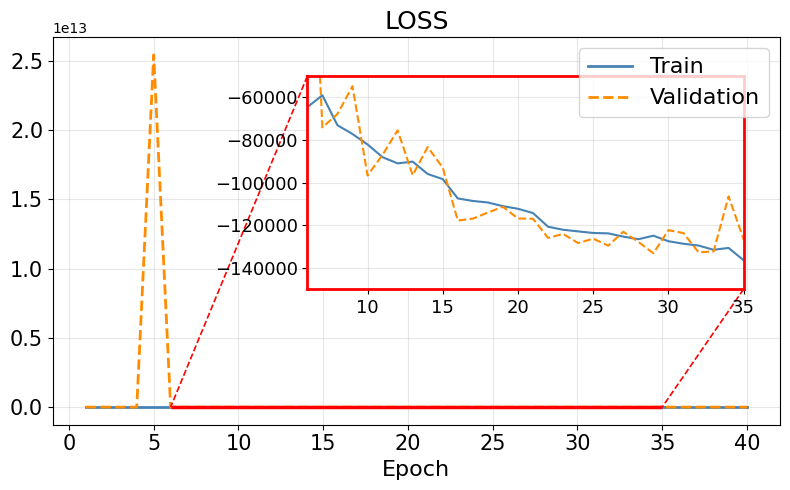

Guardado: /run/media/alejo/alejin/Kimberlina/Images/loss.png


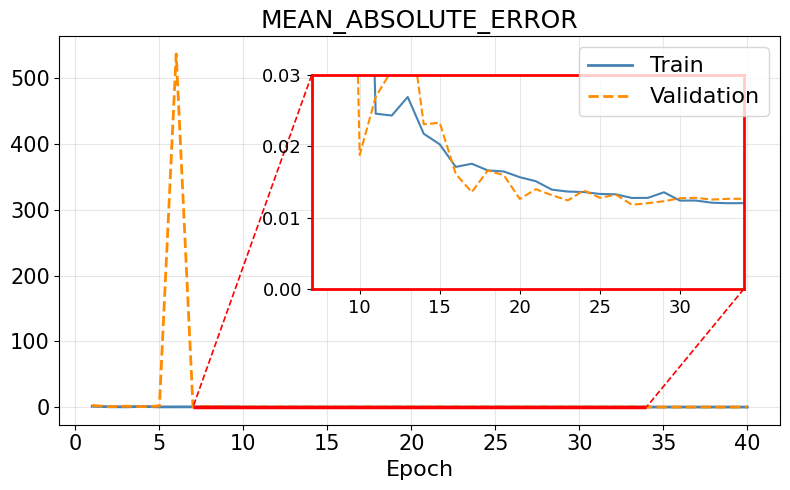

Guardado: /run/media/alejo/alejin/Kimberlina/Images/mean_absolute_error.png


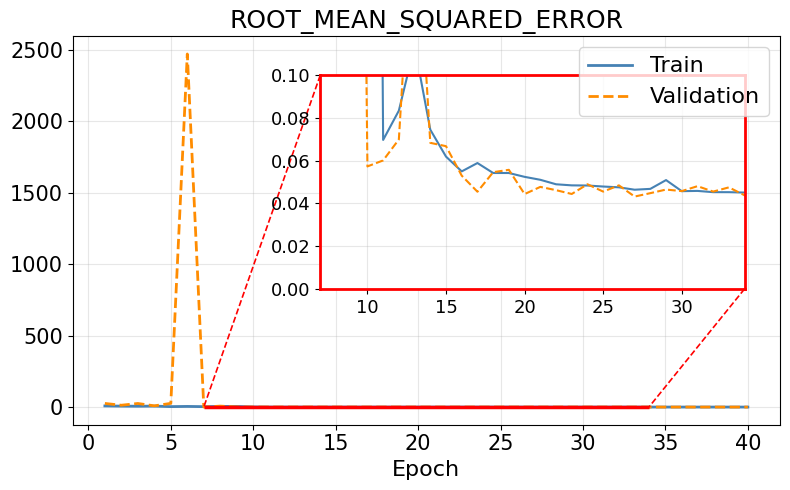

Guardado: /run/media/alejo/alejin/Kimberlina/Images/root_mean_squared_error.png


In [44]:
def plot_history_dict(h, figsize=(20, 5), limits=None, fontsize=14,
                      save_dir="/run/media/alejo/alejin/Kimberlina/Images"):
    if limits is None:
        limits = {}

    metrics = [k for k in h.keys() if not k.startswith("val_") and k != "lr"]
    epochs  = range(1, len(h[metrics[0]]) + 1)

    os.makedirs(save_dir, exist_ok=True)

    for metric in metrics:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))

        # ─── GRÁFICA PRINCIPAL ────────────────────────────────────────────────
        ax.plot(epochs, h[metric], label="Train", color="steelblue", linewidth=2)
        if f"val_{metric}" in h:
            ax.plot(epochs, h[f"val_{metric}"], label="Validation",
                    color="darkorange", linewidth=2, linestyle="--")
        ax.set_title(metric.upper(), fontsize=fontsize + 2)
        ax.set_xlabel("Epoch", fontsize=fontsize)
        ax.tick_params(labelsize=fontsize - 1)
        ax.legend(fontsize=fontsize)
        ax.grid(True, alpha=0.3)

        # ─── ZOOM EMBEBIDO ────────────────────────────────────────────────────
        if metric in limits:
            xlim  = limits[metric].get("xlim")
            ylim  = limits[metric].get("ylim")
            pad_x = limits[metric].get("pad", (0, 0))[0]
            pad_y = limits[metric].get("pad", (0, 0))[1]

            rect = patches.FancyBboxPatch(
                (xlim[0] - pad_x, ylim[0] - pad_y),
                xlim[1] - xlim[0] + 2 * pad_x,
                ylim[1] - ylim[0] + 2 * pad_y,
                boxstyle="square,pad=0",
                linewidth=2.5, edgecolor="red", facecolor="none", zorder=6
            )
            ax.add_patch(rect)

            rect_shadow = patches.FancyBboxPatch(
                (xlim[0] - pad_x, ylim[0] - pad_y),
                xlim[1] - xlim[0] + 2 * pad_x,
                ylim[1] - ylim[0] + 2 * pad_y,
                boxstyle="square,pad=0",
                linewidth=0, edgecolor="none", facecolor="red", alpha=0.08, zorder=5
            )
            ax.add_patch(rect_shadow)

            ax_inset = ax.inset_axes([0.35, 0.35, 0.6, 0.55])
            ax_inset.plot(epochs, h[metric], color="steelblue", linewidth=1.5)
            if f"val_{metric}" in h:
                ax_inset.plot(epochs, h[f"val_{metric}"],
                              color="darkorange", linewidth=1.5, linestyle="--")
            if xlim:
                ax_inset.set_xlim(xlim)
            if ylim:
                ax_inset.set_ylim(ylim)

            ax_inset.tick_params(labelsize=fontsize - 3)
            ax_inset.grid(True, alpha=0.3)
            for spine in ax_inset.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(2)

            mark_inset(ax, ax_inset, loc1=2, loc2=4,
                       fc="none", ec="red", lw=1.2, linestyle="--")

        plt.tight_layout()
        path = os.path.join(save_dir, f"{metric}.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Guardado: {path}")

# ── USO ──────────────────────────────────────────────────────────────────────
limits = {
    'loss':                    {'xlim': (6, 35), 'ylim': (-1.5e5, -0.5e5), 'pad': (0, 1e4)},
    'mean_absolute_error':     {'xlim': (7, 34), 'ylim': (0,      0.03),   'pad': (0, 0.01)},
    'root_mean_squared_error': {'xlim': (7, 34), 'ylim': (0,      0.1),    'pad': (0, 0.02)},
}

plot_history_dict(history_dict, limits=limits, fontsize=16)

## **7.2. Plot Model Results**

In [45]:
import os
import matplotlib.pyplot as plt

def plot_metric(
    h,
    metric,
    limits=None,
    fontsize=20,
    save_dir="/run/media/alejo/alejin/Kimberlina/Images"
):
    limits = limits or {}
    limits_norm = {k.lower(): v for k, v in limits.items()}

    epochs = list(range(1, len(h[metric]) + 1))

    # ─── MATCH DIRECTO ──────────────────────────────────────────
    key = metric.lower()
    xlim = None
    ylim = None
    if key in limits_norm:
        xlim = limits_norm[key].get("xlim")
        ylim = limits_norm[key].get("ylim")
        print(f"[OK] Límites aplicados: {metric} → xlim={xlim}, ylim={ylim}")
    else:
        print(f"[SIN MATCH] {metric}")

    # ─── FILTRAR POR X ──────────────────────────────────────────
    if xlim is not None:
        x_start, x_end = xlim
        idx = [i for i, e in enumerate(epochs) if x_start <= e <= x_end]
        epochs_plot = [epochs[i] for i in idx]
        train_plot  = [h[metric][i] for i in idx]
        val_key = f"val_{metric}"
        val_plot = [h[val_key][i] for i in idx] if val_key in h else None
    else:
        epochs_plot = epochs
        train_plot  = h[metric]
        val_key = f"val_{metric}"
        val_plot = h[val_key] if val_key in h else None

    # ─── GRÁFICA ────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    ax.plot(epochs_plot, train_plot, label="Train",
            color="steelblue", linewidth=2)
    if val_plot is not None:
        ax.plot(epochs_plot, val_plot, label="Validation",
                color="darkorange", linewidth=2, linestyle="--")

    if ylim is not None:
        ax.set_ylim(ylim)

    # ─── ESTILO ─────────────────────────────────────────────────
    ylabel_map = {
    "loss": "LOSS",
    "mean_absolute_error": "MAE",
    "root_mean_squared_error": "RMSE"
    }
    ax.set_ylabel(ylabel_map.get(metric.lower(), metric.upper()), fontsize=fontsize + 2)
    ax.set_xlabel("Epoch", fontsize=fontsize)
    ax.tick_params(labelsize=fontsize - 1)
    ax.legend(fontsize=fontsize)
    ax.grid(True, alpha=0.3)

    # ─── GUARDAR ────────────────────────────────────────────────
    os.makedirs(save_dir, exist_ok=True)
    print(f"[DIR] Guardando en: {save_dir}")
    print(f"[DIR EXISTS] {os.path.exists(save_dir)}")
    fig.tight_layout()
    path = os.path.join(save_dir, f"{metric}.png")
    fig.savefig(path, dpi=150)
    plt.close(fig)
    print(f"[GUARDADO] {path}")


# ─── LIMITS CON CLAVES EXACTAS ──────────────────────────────────
limits = {
    'loss': {
        'xlim': (7, 35),
        'ylim': (-1.5e5, -0.5e5)
    },
    'mean_absolute_error': {
        'xlim': (7, 35),
        'ylim': (0, 0.1)
    },
    'root_mean_squared_error': {
        'xlim': (7, 35),
        'ylim': (0, 0.4)
    },
}

plot_metric(history_dict, "loss",                    limits=limits)
plot_metric(history_dict, "mean_absolute_error",     limits=limits)
plot_metric(history_dict, "root_mean_squared_error", limits=limits)

[OK] Límites aplicados: loss → xlim=(7, 35), ylim=(-150000.0, -50000.0)
[DIR] Guardando en: /run/media/alejo/alejin/Kimberlina/Images
[DIR EXISTS] True
[GUARDADO] /run/media/alejo/alejin/Kimberlina/Images/loss.png
[OK] Límites aplicados: mean_absolute_error → xlim=(7, 35), ylim=(0, 0.1)
[DIR] Guardando en: /run/media/alejo/alejin/Kimberlina/Images
[DIR EXISTS] True
[GUARDADO] /run/media/alejo/alejin/Kimberlina/Images/mean_absolute_error.png
[OK] Límites aplicados: root_mean_squared_error → xlim=(7, 35), ylim=(0, 0.4)
[DIR] Guardando en: /run/media/alejo/alejin/Kimberlina/Images
[DIR EXISTS] True
[GUARDADO] /run/media/alejo/alejin/Kimberlina/Images/root_mean_squared_error.png


In [46]:
#y_pred_train = model2.predict(train_seq)
y_pred_val = model2.predict(val_seq)
#y_pred_val = model2.predict(val_seq)

554/554 [==============================] - 191s 343ms/step


In [47]:
y_pred_val.shape

(4430, 288, 96, 1)

In [48]:
val_seq[0][1].shape

(8, 288, 96, 1)

# **8. Pixel Calibration**

In [53]:
from tqdm import tqdm
import tensorflow as tf

nSamplesBatch = n_val_batches  # número de batches a usar
S = 5
img_true_list = []
img_pred_list = []
img_std_list  = []

pbar = tqdm(range(nSamplesBatch), desc="Procesando batches")
for batch_id in pbar:
    x_batch, y_true = val_seq[batch_id]
    batch_size_actual = x_batch.shape[0]

    # Repite el batch S veces en el eje 0 -> 1 sola llamada al modelo en vez de S
    x_rep = tf.repeat(x_batch, repeats=S, axis=0)  # (S*batch, H, W, C)

    preds_dist = model2(x_rep)
    mus_flat   = preds_dist.mean().numpy()      # (S*batch, H, W, 1)
    sig2s_flat = preds_dist.variance().numpy()  # (S*batch, H, W, 1)

    # Reordena a (S, batch, H, W, 1)
    mus   = mus_flat.reshape(S, batch_size_actual, *mus_flat.shape[1:])
    sig2s = sig2s_flat.reshape(S, batch_size_actual, *sig2s_flat.shape[1:])

    y_pred_mean   = np.mean(mus, axis=0)
    epistemic_var = np.var(mus, axis=0)
    aleatoric_var = np.mean(sig2s, axis=0)
    total_std     = np.sqrt(epistemic_var + aleatoric_var)

    for idx_ejemplo in range(batch_size_actual):
        img_true = y_true[idx_ejemplo, ..., 0]
        img_true = img_true.numpy() if hasattr(img_true, "numpy") else img_true
        img_pred = y_pred_mean[idx_ejemplo, ..., 0]
        img_std  = total_std[idx_ejemplo, ..., 0]
        img_true_list.append(img_true)
        img_pred_list.append(img_pred)
        img_std_list.append(img_std)

    pbar.set_postfix({"ejemplos": len(img_true_list)})

print(f"Total de ejemplos acumulados: {len(img_true_list)} "
      f"(= {nSamplesBatch} batches x {batch_size_actual} ejemplos/batch)")

Procesando batches: 100%|█████████████████████| 320/320 [12:26<00:00,  2.33s/it, ejemplos=2560]

Total de ejemplos acumulados: 2560 (= 320 batches x 8 ejemplos/batch)


In [54]:
import uncertainty_toolbox as uct

In [70]:
# Apilar todos los ejemplos -> (N, H, W)
img_true_arr = np.stack(img_true_list, axis=0)
img_pred_arr = np.stack(img_pred_list, axis=0)
img_std_arr  = np.stack(img_std_list, axis=0)
N, H, W = img_true_arr.shape

# Separar N (ejemplos) de H*W (píxeles)
y_flat     = img_true_arr.reshape(N, H * W)
preds_flat = img_pred_arr.reshape(N, H * W)
std_flat   = img_std_arr.reshape(N, H * W)

# --- Selecciona aquí el pixel de interés ---
fila_interes    = 30   # cambia este valor (0 a H-1)
columna_interes = 30   # cambia este valor (0 a W-1)

pixeles_interes = [(fila_interes, columna_interes)]  # lista de (fila, columna) a evaluar
n_pixels = len(pixeles_interes)

# Vectores para almacenar las 3 métricas de calibración, una por pixel
mace_vec  = np.zeros(n_pixels)
rmsce_vec = np.zeros(n_pixels)
ma_vec    = np.zeros(n_pixels)

for i, (fila, columna) in enumerate(pixeles_interes):
    p = np.ravel_multi_index((fila, columna), (H, W))  # convierte (fila, columna) -> índice plano

    predictions     = preds_flat[:, p]
    predictions_std = std_flat[:, p]
    y               = y_flat[:, p]

    metrics = uct.metrics.get_all_metrics(predictions, predictions_std, y)
    cal = metrics["avg_calibration"]

    if i == 0:
        print("Claves de avg_calibration:", cal.keys())
        print(f"Evaluando pixel (fila={fila}, columna={columna}) -> índice plano {p}")

    mace_vec[i]  = cal["ma_cal"]
    rmsce_vec[i] = cal["rms_cal"]
    ma_vec[i]    = cal["miscal_area"]

print(f"MACE: {mace_vec[0]:.4f}, RMSCE: {rmsce_vec[0]:.4f}, MA: {ma_vec[0]:.4f}")

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.77it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.35it/s]

 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.000
  RMSE          0.000
  MDAE          0.000
  MARPD         0.039
  R2            -1.548
  Correlation   0.561
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.200
  Mean-absolute Calibration Error       0.175
  Miscalibration Area                   0.176
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.185
     Group Size: 0.56 -- Calibration Error: 0.177
     Group Size: 1.00 -- Calibration Error: 0.175
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.211
     Group Size: 0.56 -- Calibration Error: 0.203
     Group Size: 1.00 -- Calibration Error: 0.200
===============

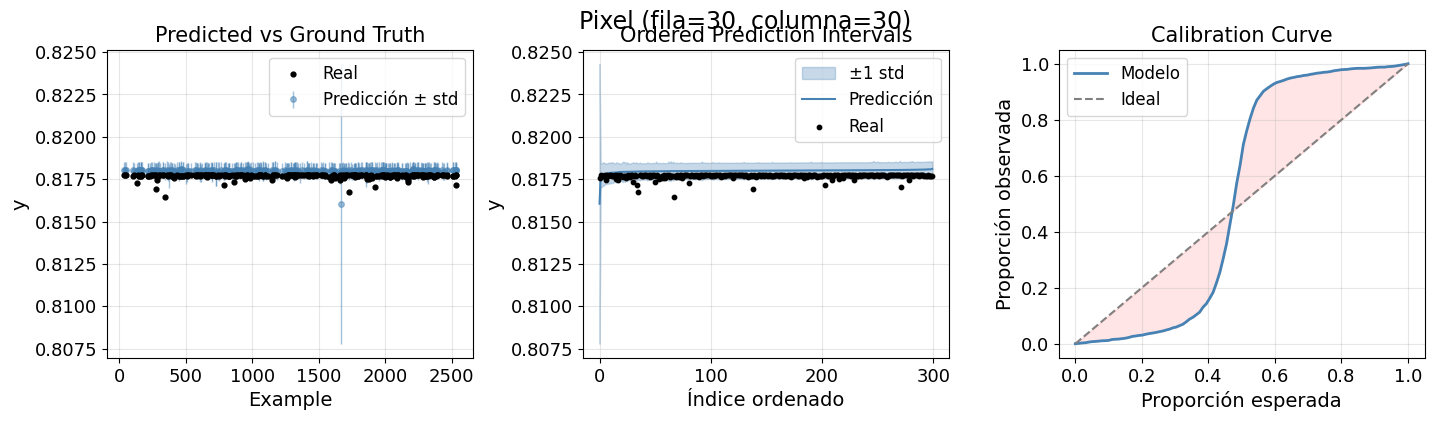

Pixel (fila=30, columna=30) -> MACE: 0.1747, RMSCE: 0.1999, MA: 0.1763


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct

p = np.ravel_multi_index((fila_interes, columna_interes), (H, W))
predictions     = preds_flat[:, p]
predictions_std = std_flat[:, p]
y               = y_flat[:, p]
x               = np.arange(len(y))

def make_plots_manual(pred_mean, pred_std, y, x, fontsize=14,
                       n_subset=300, plot_save_str=None, savefig=False):
    n = len(y)
    n_subset = min(n_subset, n)
    idx = np.random.choice(n, n_subset, replace=False) if n > n_subset else np.arange(n)
    idx.sort()

    fig, axs = plt.subplots(1, 3, figsize=(17, 4))

    # ─── 1) XY con barras de error (equivalente a plot_xy) ──────────────
    ax = axs[0]
    ax.errorbar(x[idx], pred_mean[idx], yerr=pred_std[idx],
                fmt="o", ms=4, color="steelblue", ecolor="steelblue",
                alpha=0.5, elinewidth=1, capsize=0, label="Predicción ± std")
    ax.scatter(x[idx], y[idx], color="black", s=12, zorder=5, label="Real")
    ax.set_xlabel("Example", fontsize=fontsize)
    ax.set_ylabel("y", fontsize=fontsize)
    ax.set_title("Predicted vs Ground Truth", fontsize=fontsize + 1)
    ax.tick_params(labelsize=fontsize - 1)
    ax.legend(fontsize=fontsize - 2)
    ax.grid(True, alpha=0.3)

    # ─── 2) Intervalos ordenados por valor predicho ──────────────────────
    ax = axs[1]
    order = np.argsort(pred_mean)
    order = order[np.isin(order, idx)]  # mismo subset, ordenado
    xx = np.arange(len(order))
    ax.fill_between(xx,
                     (pred_mean - pred_std)[order],
                     (pred_mean + pred_std)[order],
                     color="steelblue", alpha=0.3, label="±1 std")
    ax.plot(xx, pred_mean[order], color="steelblue", lw=1.5, label="Predicción")
    ax.scatter(xx, y[order], color="black", s=10, zorder=5, label="Real")
    ax.set_xlabel("Índice ordenado", fontsize=fontsize)
    ax.set_ylabel("y", fontsize=fontsize)
    ax.set_title("Ordered Prediction Intervals", fontsize=fontsize + 1)
    ax.tick_params(labelsize=fontsize - 1)
    ax.legend(fontsize=fontsize - 2)
    ax.grid(True, alpha=0.3)

    # ─── 3) Curva de calibración (equivalente a plot_calibration) ────────
    ax = axs[2]
    exp_props, obs_props = uct.get_proportion_lists_vectorized(
        pred_mean, pred_std, y, prop_type="interval"
    )
    ax.plot(exp_props, obs_props, color="steelblue", lw=2, label="Modelo")
    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Ideal")
    ax.fill_between(exp_props, exp_props, obs_props, color="red", alpha=0.1)
    ax.set_xlabel("Proporción esperada", fontsize=fontsize)
    ax.set_ylabel("Proporción observada", fontsize=fontsize)
    ax.set_title("Calibration Curve", fontsize=fontsize + 1)
    ax.tick_params(labelsize=fontsize - 1)
    ax.legend(fontsize=fontsize - 2)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Pixel (fila={fila_interes}, columna={columna_interes})", fontsize=fontsize + 3)
    fig.subplots_adjust(wspace=0.3)

    if savefig and plot_save_str:
        fig.savefig(f"{plot_save_str}.svg", bbox_inches="tight", facecolor="white")

    plt.show()

# ── USO ──────────────────────────────────────────────────────────────────
make_plots_manual(predictions, predictions_std, y, x, fontsize=14,
                   plot_save_str=f"pixel_{fila_interes}_{columna_interes}",
                   savefig=False)

mace  = uct.mean_absolute_calibration_error(predictions, predictions_std, y)
rmsce = uct.root_mean_squared_calibration_error(predictions, predictions_std, y)
ma    = uct.miscalibration_area(predictions, predictions_std, y)
print(f"Pixel (fila={fila_interes}, columna={columna_interes}) -> MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")

In [72]:
p = np.ravel_multi_index((fila_interes, columna_interes), (H, W))

predictions     = preds_flat[:, p]
predictions_std = std_flat[:, p]
y               = y_flat[:, p]

# --- Recalibración ---
std_recalibrator = uct.recalibration.get_std_recalibrator(
    predictions, predictions_std, y
)
pred_std_recal = std_recalibrator(predictions_std)  # nuevas std recalibradas

print(f"Recalibración aplicada al pixel (fila={fila_interes}, columna={columna_interes})")

Recalibración aplicada al pixel (fila=30, columna=30)


In [73]:
metrics_recal = uct.metrics.get_all_metrics(predictions, pred_std_recal, y)
cal_recal = metrics_recal["avg_calibration"]

mace_recal  = cal_recal["ma_cal"]
rmsce_recal = cal_recal["rms_cal"]
ma_recal    = cal_recal["miscal_area"]

print(f"ANTES  -> MACE: {mace:.4f}, RMSCE: {rmsce:.4f}, MA: {ma:.4f}")
print(f"DESPUÉS -> MACE: {mace_recal:.4f}, RMSCE: {rmsce_recal:.4f}, MA: {ma_recal:.4f}")

 (1/n) Calculating accuracy metrics
 (2/n) Calculating average calibration metrics
 (3/n) Calculating adversarial group calibration metrics
  [1/2] for mean absolute calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.99it/s]


  [2/2] for root mean squared calibration error
Measuring adversarial group calibration by spanning group size between 0.0 and 1.0, in 10 intervals


100%|██████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 12.80it/s]

 (4/n) Calculating sharpness metrics
 (n/n) Calculating proper scoring rule metrics
**Finished Calculating All Metrics**


===================== Accuracy Metrics =====================
  MAE           0.000
  RMSE          0.000
  MDAE          0.000
  MARPD         0.039
  R2            -1.548
  Correlation   0.561
=============== Average Calibration Metrics ================
  Root-mean-squared Calibration Error   0.195
  Mean-absolute Calibration Error       0.171
  Miscalibration Area                   0.172
========== Adversarial Group Calibration Metrics ===========
  Mean-absolute Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.178
     Group Size: 0.56 -- Calibration Error: 0.173
     Group Size: 1.00 -- Calibration Error: 0.171
  Root-mean-squared Adversarial Group Calibration Error
     Group Size: 0.11 -- Calibration Error: 0.206
     Group Size: 0.56 -- Calibration Error: 0.197
     Group Size: 1.00 -- Calibration Error: 0.195
===============

Figure saved to: ../Images/calibration_pixel_30_30.png


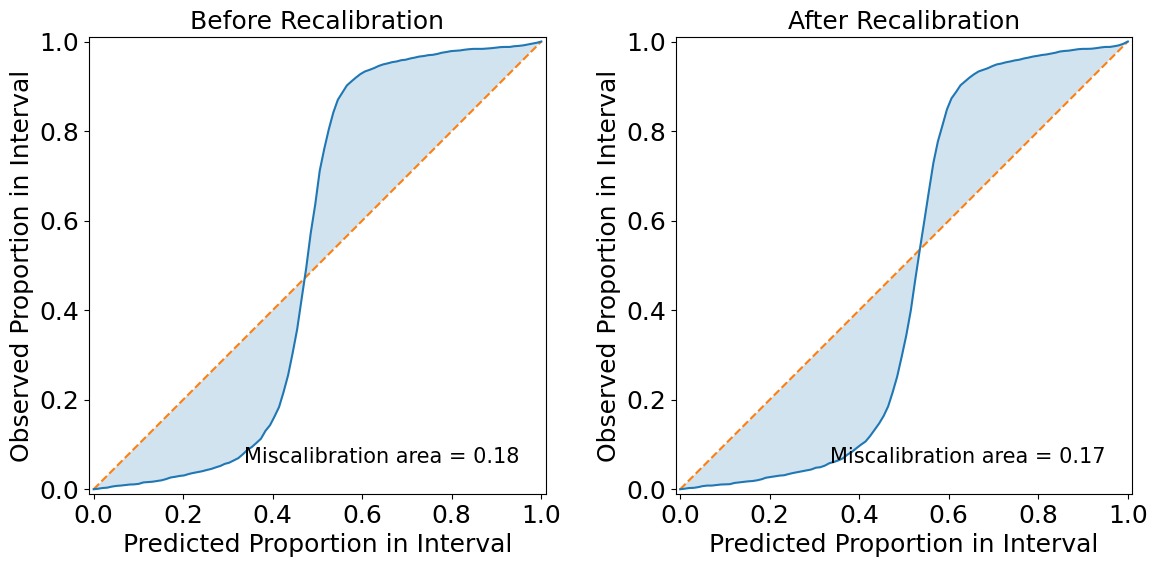

In [74]:
# -------------------------------
# Parámetros de fuente (mismo estilo que las otras figuras)
# -------------------------------
sizefont = 18
plt.rcParams.update({
    "font.size":       sizefont,
    "axes.titlesize":  sizefont,
    "axes.labelsize":  sizefont,
    "xtick.labelsize": sizefont,
    "ytick.labelsize": sizefont,
})

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0] = uct.plot_calibration(predictions, predictions_std, y, ax=axs[0])
axs[0].set_title("Before Recalibration", fontsize=sizefont)

axs[1] = uct.plot_calibration(predictions, pred_std_recal, y, ax=axs[1])
axs[1].set_title("After Recalibration", fontsize=sizefont)

fig.tight_layout()

save_path = os.path.join(dirImages, f"calibration_pixel_{fila_interes}_{columna_interes}.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {save_path}")

plt.show()

# **9. Full Image Recalibration**

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct
import os

# --- Stack all examples -> (N, H, W) ---
img_true_arr = np.stack(img_true_list, axis=0)
img_pred_arr = np.stack(img_pred_list, axis=0)
img_std_arr  = np.stack(img_std_list, axis=0)
N, H, W = img_true_arr.shape

# --- Flatten pixels: (N, H*W) ---
y_flat     = img_true_arr.reshape(N, H * W)
preds_flat = img_pred_arr.reshape(N, H * W)
std_flat   = img_std_arr.reshape(N, H * W)

n_pixels = H * W

# --- Arrays to store miscalibration area before/after recalibration ---
ma_before = np.zeros(n_pixels)
ma_after  = np.zeros(n_pixels)

In [76]:
n_pixels

27648

In [80]:
import numpy as np
import time
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import uncertainty_toolbox as uct

# --- Función que procesa UN pixel (debe estar a nivel de módulo para multiprocessing) ---
# --- Función que procesa UN pixel (debe estar a nivel de módulo para multiprocessing) ---
def process_pixel(args):
    p, predictions, predictions_std, y = args

    # Miscalibración antes de recalibrar
    ma_before_p = uct.miscalibration_area(predictions, predictions_std, y)

    # Ratio óptimo de recalibración (esto ES el "modelo": un solo número)
    std_recal_ratio = uct.recalibration.optimize_recalibration_ratio(
        predictions, predictions_std, y, criterion="ma_cal"
    )

    # Aplicar el ratio (equivalente exacto a std_recalibrator(predictions_std))
    pred_std_recal = std_recal_ratio * predictions_std

    # Miscalibración después de recalibrar
    ma_after_p = uct.miscalibration_area(predictions, pred_std_recal, y)

    return p, ma_before_p, ma_after_p, std_recal_ratio, pred_std_recal

In [81]:
tasks = [
    (p, preds_flat[:, p], std_flat[:, p], y_flat[:, p])
    for p in range(n_pixels)
]

ma_before        = np.zeros(n_pixels)
ma_after         = np.zeros(n_pixels)
std_recal_ratios = np.zeros(n_pixels)          # ← el "modelo" de cada pixel

N = preds_flat.shape[0]
pred_std_recal_all = np.zeros((N, n_pixels))

In [82]:
N_CORES = 14
print(f"Núcleos disponibles: {os.cpu_count()} | Usando: {N_CORES}")

t0 = time.time()
with ProcessPoolExecutor(max_workers=N_CORES) as executor:
    futures = [executor.submit(process_pixel, task) for task in tasks]
    for future in tqdm(as_completed(futures), total=n_pixels, desc="Processing pixels"):
        p, ma_b, ma_a, ratio, pred_std_recal_p = future.result()
        ma_before[p]           = ma_b
        ma_after[p]            = ma_a
        std_recal_ratios[p]    = ratio
        pred_std_recal_all[:, p] = pred_std_recal_p
t1 = time.time()

print(f"\nTiempo total: {(t1 - t0)/60:.2f} min")
print(f"Tiempo promedio por pixel: {(t1 - t0)/n_pixels:.4f} s")

Núcleos disponibles: 16 | Usando: 14


Processing pixels: 100%|███████████████████████████████| 27648/27648 [8:50:23<00:00,  1.15s/it]



Tiempo total: 530.44 min
Tiempo promedio por pixel: 1.1511 s


In [83]:
# =========================================================
# 4) Reshape a dimensiones de imagen (H, W)
# =========================================================
ma_before_map        = ma_before.reshape(H, W)
ma_after_map         = ma_after.reshape(H, W)
std_recal_ratio_map  = std_recal_ratios.reshape(H, W)   # ← "mapa de modelos", uno por pixel

# **10. Save Recalibration Model**

In [84]:
# =========================================================
# 5) Guardar todo lo necesario para recalibrar en el futuro
# =========================================================
save_dir = dirModel
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "std_recal_ratio_map.npy"), std_recal_ratio_map)
np.save(os.path.join(save_dir, "ma_before_map.npy"),       ma_before_map)
np.save(os.path.join(save_dir, "ma_after_map.npy"),        ma_after_map)
np.save(os.path.join(save_dir, "pred_std_recal_all.npy"),  pred_std_recal_all)

# Metadata para saber exactamente cómo se generó este "modelo"
metadata = {
    "criterion": "ma_cal",
    "optimizer_bounds": [1e-2, 1e2],
    "H": int(H),
    "W": int(W),
    "n_pixels": int(n_pixels),
    "descripcion": "std_recal_ratio_map[i, j] es el factor escalar tal que "
                   "std_recalibrado = ratio * std_predicho, obtenido con "
                   "uct.recalibration.optimize_recalibration_ratio",
}
with open(os.path.join(save_dir, "std_recal_ratio_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("\nGuardado en:", save_dir)
print(" - std_recal_ratio_map.npy   (el modelo de recalibración por pixel)")
print(" - ma_before_map.npy")
print(" - ma_after_map.npy")
print(" - pred_std_recal_all.npy")
print(" - std_recal_ratio_metadata.json")


Guardado en: ../Model/
 - std_recal_ratio_map.npy   (el modelo de recalibración por pixel)
 - ma_before_map.npy
 - ma_after_map.npy
 - pred_std_recal_all.npy
 - std_recal_ratio_metadata.json
